In [1]:
import uproot
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import ROOT
import awkward as ak
from yaml import safe_load
from math import sqrt

Welcome to JupyROOT 6.28/10


In [2]:
# Config and yaml file must be in this directory by default
# Absolute path must be supplied for the script to work in batch mode
configPath = '/r01/lhcb/ejnw2/fcc/FCCAnalyses/examples/FCCee/flavour/B2Inv'
sys.path.append(os.path.abspath(configPath))
import config as cfg

## Look at correlations - Currently old data as current data still processing (with correct BSC)


n.b. for old_andOincorrectBSC added extra variables whilst still processing ud so some ud files have extra variables -> cant compile ud into one file

In [8]:
import seaborn as sns
sns_plot = sns.clustermap(df_full.corr(), cmap="rocket_r")

ModuleNotFoundError: No module named 'seaborn'

## Set up for full data

In [3]:
# Read list of feature names used in the BDT from the config YAML file
with open(cfg.fccana_opts['yamlPath']) as stream:
    yaml = safe_load(stream)
    BDT2branchList = yaml[cfg.bdt2_opts['mvaBranchList']]

In [4]:
BDT2branchList

['EVT_sum_Rec_vtx_ntracks_exclPV',
 'EVT_hemisEmin_sum_Rec_vtx_ntracks_exclPV',
 'EVT_hemisEmax_sum_Rec_vtx_ntracks_exclPV',
 'EVT_hemisEmax_nDV',
 'Rec_track_absd0_max_hemisEmin',
 'Rec_track_absd0_ave_hemisEmin',
 'Rec_track_absd0chi2_max_hemisEmin',
 'Rec_track_absd0chi2_ave_hemisEmin',
 'Rec_track_absz0_max_hemisEmin',
 'Rec_track_absz0_ave_hemisEmin',
 'Rec_track_absz0chi2_max_hemisEmin',
 'Rec_track_absz0chi2_ave_hemisEmin',
 'Rec_track_absz0_min_hemisEmin',
 'Rec_track_absz0chi2_min_hemisEmin',
 'EVT_hemisEmin_maxpChargedRP_p',
 'EVT_hemisEmin_maxpChargedRP_fromPV',
 'EVT_hemisEmax_maxpChargedRP_p',
 'EVT_hemisEmax_maxpChargedRP_fromPV',
 'EVT_hemisEmin_maxpChargedRP_px',
 'EVT_hemisEmin_maxpChargedRP_py',
 'EVT_hemisEmin_maxpChargedRP_pz',
 'EVT_unitThrust_x',
 'EVT_unitThrust_y',
 'EVT_unitThrust_z',
 'Rec_vtx_ntracks_max_hemisEmin',
 'Rec_vtx_ntracks_max_hemisEmax',
 'Rec_thrustCosTheta_max_hemisEmin',
 'Rec_thrustCosTheta_ave_hemisEmin',
 'Rec_thrustCosTheta_max_hemisEmax',


In [5]:
BDT2branchList_subset = [ 'EVT_unitThrust_x',
 'EVT_unitThrust_y',
 'EVT_unitThrust_z',
 'EVT_hemisEmin_maxpChargedRP_px',
 'EVT_hemisEmin_maxpChargedRP_py',
 'EVT_hemisEmin_maxpChargedRP_pz', #from here and above basically no correlation, dont think will include
'EVT_sum_Rec_vtx_ntracks_exclPV',
 'EVT_hemisEmin_sum_Rec_vtx_ntracks_exclPV',
 'EVT_hemisEmax_sum_Rec_vtx_ntracks_exclPV',
 'EVT_hemisEmax_nDV', #nb. was in twice
 'Rec_track_absd0_max_hemisEmin',
 'Rec_track_absd0_ave_hemisEmin',
 'Rec_track_absd0chi2_max_hemisEmin',
 'Rec_track_absd0chi2_ave_hemisEmin',
 'Rec_track_absz0_max_hemisEmin',
 'Rec_track_absz0_ave_hemisEmin',
 'Rec_track_absz0chi2_max_hemisEmin',
 'Rec_track_absz0chi2_ave_hemisEmin',
 'Rec_track_absz0_min_hemisEmin',
 'Rec_track_absz0chi2_min_hemisEmin',
 'EVT_hemisEmin_maxpChargedRP_p',
 'EVT_hemisEmin_maxpChargedRP_fromPV',
 'EVT_hemisEmax_maxpChargedRP_p',
 'EVT_hemisEmax_maxpChargedRP_fromPV',
 'Rec_vtx_ntracks_max_hemisEmin',
 'Rec_vtx_ntracks_max_hemisEmax',
 'Rec_thrustCosTheta_max_hemisEmin',
 'Rec_thrustCosTheta_ave_hemisEmin',
 'Rec_thrustCosTheta_max_hemisEmax',
 'Rec_thrustCosTheta_ave_hemisEmax',
 'Rec_vtx_thrustCosTheta_max_hemisEmin', #nb. was in twice
 'Rec_vtx_thrustCosTheta_ave_hemisEmin', #nb. was in twice
 'Rec_vtx_thrustCosTheta_max_hemisEmax', #nb. was in twice
 'Rec_vtx_thrustCosTheta_ave_hemisEmax', #nb. was in twice
 'Rec_vtx_d2PV_max_hemisEmin',
 'EVT_Thrust_deltaE',
 'EVT_hemisEmin_Emiss',
 'EVT_e',
 'Rec_thrustCosTheta_min_hemisEmin',
 'Rec_thrustCosTheta_min_hemisEmax',
 'PV_Rec_vtx_m',
 'Rec_PV_ntracks',
 'Rec_track_n',
 'Rec_track_absd0_max_hemisEmax',
 'Rec_track_absd0_ave_hemisEmax',
 'Rec_track_absd0chi2_max_hemisEmax',
 'Rec_track_absd0chi2_ave_hemisEmax',
 'Rec_track_absz0_max_hemisEmax',
 'Rec_track_absz0_ave_hemisEmax',
 'Rec_track_absz0chi2_max_hemisEmax',
 'Rec_track_absz0chi2_ave_hemisEmax',
 'Rec_vtx_d2PV_max_hemisEmax',
 'Rec_vtx_d2PV_ave_hemisEmax',
 'Rec_vtx_d2PV_min_hemisEmax',
 'Rec_track_absd0_min_hemisEmin',
 'Rec_track_absd0chi2_min_hemisEmin',
 'Rec_track_absz0chi2_min_hemisEmax',
 'Rec_track_absd0chi2_min_hemisEmax',
 'Rec_track_absd0_min_hemisEmax',
 'Rec_track_absz0_min_hemisEmax',
]
#require subset as these ones are in stupid format so need to clean up first :(
'''
 'EVT_sum_Rec_px',
 'EVT_sum_Rec_py',
 'EVT_sum_Rec_pz',
 'EVT_p',
'''

"\n 'EVT_sum_Rec_px',\n 'EVT_sum_Rec_py',\n 'EVT_sum_Rec_pz',\n 'EVT_p',\n"

In [6]:
merged_folder_path = '/r01/lhcb/ejnw2/fcc/FCCAnalyses/examples/FCCee/flavour/B2Inv/outputs/stage2_training_incorrectBSC/full_data_merged/'
#list = ['p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu','p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu','p8_ee_Zbb_ecm91','p8_ee_Zcc_ecm91','p8_ee_Zss_ecm91', 'p8_ee_Zud_ecm91', 'p8_ee_Ztautau_ecm91']
list = cfg.samples

sample = 'p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu'
merged_file_path = merged_folder_path + f"{sample}_allchunks.root"

# Create instance of uproot, we have opened the file
uproot_file = uproot.open( merged_file_path )

tree = uproot_file['events']

# define variables we want out
branches = BDT2branchList_subset
#branches = BDT2branchList_corrected 

df_Bs_merged = tree.arrays(
    expressions = branches , 
    library = 'pd' ,
)
    
# close file
uproot_file.close()

In [7]:
df_Bs_merged

,EVT_unitThrust_x,EVT_unitThrust_y,EVT_unitThrust_z,EVT_hemisEmin_maxpChargedRP_px,EVT_hemisEmin_maxpChargedRP_py,EVT_hemisEmin_maxpChargedRP_pz,EVT_sum_Rec_vtx_ntracks_exclPV,EVT_hemisEmin_sum_Rec_vtx_ntracks_exclPV,EVT_hemisEmax_sum_Rec_vtx_ntracks_exclPV,EVT_hemisEmax_nDV,...,Rec_track_absz0chi2_ave_hemisEmax,Rec_vtx_d2PV_max_hemisEmax,Rec_vtx_d2PV_ave_hemisEmax,Rec_vtx_d2PV_min_hemisEmax,Rec_track_absd0_min_hemisEmin,Rec_track_absd0chi2_min_hemisEmin,Rec_track_absz0chi2_min_hemisEmax,Rec_track_absd0chi2_min_hemisEmax,Rec_track_absd0_min_hemisEmax,Rec_track_absz0_min_hemisEmax
0,-0.639538,0.747891,-0.177904,-2.091565,2.520754,-0.719667,3.0,0.0,3.0,1.0,...,155.047867,0.440979,0.440979,0.440979,0.000518,0.094079,4.597307,0.302317,0.003544,0.201228
1,0.575874,0.662344,-0.479238,1.326866,2.281882,-1.570009,2.0,0.0,2.0,1.0,...,368.074249,0.437079,0.437079,0.437079,0.000280,0.019338,298.007050,0.359852,0.005228,0.973876
2,-0.891390,0.185641,-0.413476,-3.721605,1.104980,-1.100865,5.0,0.0,5.0,2.0,...,230.679947,17.493578,14.322830,11.152082,0.001972,0.301005,70.701073,0.268420,0.004904,0.278002
3,-0.485858,-0.251646,0.837028,-2.822439,-2.595847,3.325588,5.0,0.0,5.0,2.0,...,175.775909,14.529846,11.398128,8.266409,0.005534,0.096196,0.118887,0.042012,0.002236,0.002340
4,-0.722256,0.551214,-0.417744,-2.033326,-1.309650,-0.473853,7.0,0.0,7.0,3.0,...,343.917542,152.426361,54.616779,1.654899,0.001417,0.037801,18.080868,0.052257,0.000376,0.058070
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
699027,0.377647,-0.916788,-0.129933,-0.131017,-0.131207,-0.248849,6.0,0.0,6.0,3.0,...,191.712631,4.656139,3.699877,2.142287,0.017195,0.205657,66.776115,1.449233,0.065206,0.356306
699028,0.899526,-0.318323,-0.299207,0.227623,-0.548312,0.866677,0.0,0.0,0.0,0.0,...,34.044609,0.000000,0.000000,0.000000,0.016822,0.620147,9.825068,0.060434,0.000399,0.048978
699029,-0.115025,-0.650437,0.750800,-0.024224,-2.361251,2.444290,3.0,0.0,3.0,1.0,...,36.504124,1.745073,1.745073,1.745073,0.001083,0.061833,1.006311,0.783485,0.024544,0.056517
699030,0.510727,0.389146,-0.766631,0.892232,1.255337,-2.504779,7.0,2.0,5.0,2.0,...,73.950142,1.065013,0.782798,0.500583,0.025775,1.650915,2.778838,0.090550,0.001901,0.266720


In [8]:
problem_children= [ 'EVT_sum_Rec_px',
 'EVT_sum_Rec_py',
 'EVT_sum_Rec_pz',
 'EVT_p',]

In [9]:
merged_folder_path = '/r01/lhcb/ejnw2/fcc/FCCAnalyses/examples/FCCee/flavour/B2Inv/outputs/stage2_training_incorrectBSC/full_data_merged/'
#list = ['p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu','p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu','p8_ee_Zbb_ecm91','p8_ee_Zcc_ecm91','p8_ee_Zss_ecm91', 'p8_ee_Zud_ecm91', 'p8_ee_Ztautau_ecm91']
list = cfg.samples

sample = 'p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu'
merged_file_path = merged_folder_path + f"{sample}_allchunks.root"

# Create instance of uproot, we have opened the file
uproot_file = uproot.open( merged_file_path )

tree = uproot_file['events']

# define variables we want out
branches = problem_children
#branches = BDT2branchList_corrected 

df_problem_children = tree.arrays(
    expressions = branches , 
    library = 'pd' ,
)
    
# close file
uproot_file.close()

In [10]:
df_problem_children

,EVT_sum_Rec_px,EVT_sum_Rec_py,EVT_sum_Rec_pz,EVT_p
0,[21.895362854003906],[-19.434553146362305],[7.427690505981445],[30.203962326049805]
1,[-17.517547607421875],[-19.724275588989258],[15.520214080810547],[30.60700225830078]
2,[30.690937042236328],[-5.260426998138428],[12.176152229309082],[33.434478759765625]
3,[14.013197898864746],[15.373281478881836],[-15.869317054748535],[26.163766860961914]
4,[20.24200439453125],[-25.841991424560547],[12.332839012145996],[35.06631088256836]
...,...,...,...,...
699027,[-11.36876392364502],[26.208213806152344],[3.5140938758850098],[28.783123016357422]
699028,[-28.73676872253418],[9.93168830871582],[22.551816940307617],[37.85531234741211]
699029,[4.80675745010376],[22.572900772094727],[-28.298248291015625],[36.51618194580078]
699030,[-19.04315185546875],[-13.072078704833984],[28.056312561035156],[36.34112548828125]


In [11]:
type(df_problem_children['EVT_sum_Rec_px'][0])

awkward.highlevel.Array

In [12]:
# Function to extract the first element from an awkward array
def select_first_element(x):
    if isinstance(x, ak.highlevel.Array):
        return np.array(x)[0]
    return x

# Apply the function to the entire DataFrame using list comprehension
df_cleaned = pd.DataFrame({
    col: [select_first_element(x) for x in df_problem_children[col]]
    for col in df_problem_children.columns
})

print(df_cleaned)


        EVT_sum_Rec_px  EVT_sum_Rec_py  EVT_sum_Rec_pz      EVT_p
0            21.895363      -19.434553        7.427691  30.203962
1           -17.517548      -19.724276       15.520214  30.607002
2            30.690937       -5.260427       12.176152  33.434479
3            14.013198       15.373281      -15.869317  26.163767
4            20.242004      -25.841991       12.332839  35.066311
...                ...             ...             ...        ...
699027      -11.368764       26.208214        3.514094  28.783123
699028      -28.736769        9.931688       22.551817  37.855312
699029        4.806757       22.572901      -28.298248  36.516182
699030      -19.043152      -13.072079       28.056313  36.341125
699031       25.199680       14.004063        8.273813  29.993227

[699032 rows x 4 columns]


In [13]:
df_cleaned

,EVT_sum_Rec_px,EVT_sum_Rec_py,EVT_sum_Rec_pz,EVT_p
0,21.895363,-19.434553,7.427691,30.203962
1,-17.517548,-19.724276,15.520214,30.607002
2,30.690937,-5.260427,12.176152,33.434479
3,14.013198,15.373281,-15.869317,26.163767
4,20.242004,-25.841991,12.332839,35.066311
...,...,...,...,...
699027,-11.368764,26.208214,3.514094,28.783123
699028,-28.736769,9.931688,22.551817,37.855312
699029,4.806757,22.572901,-28.298248,36.516182
699030,-19.043152,-13.072079,28.056313,36.341125


In [14]:
# Add to full correlation plot
df_Bs_full = pd.concat([df_Bs_merged,df_cleaned],axis=1)


Text(0.5, 1.0, 'Bs Correlation Matrix')

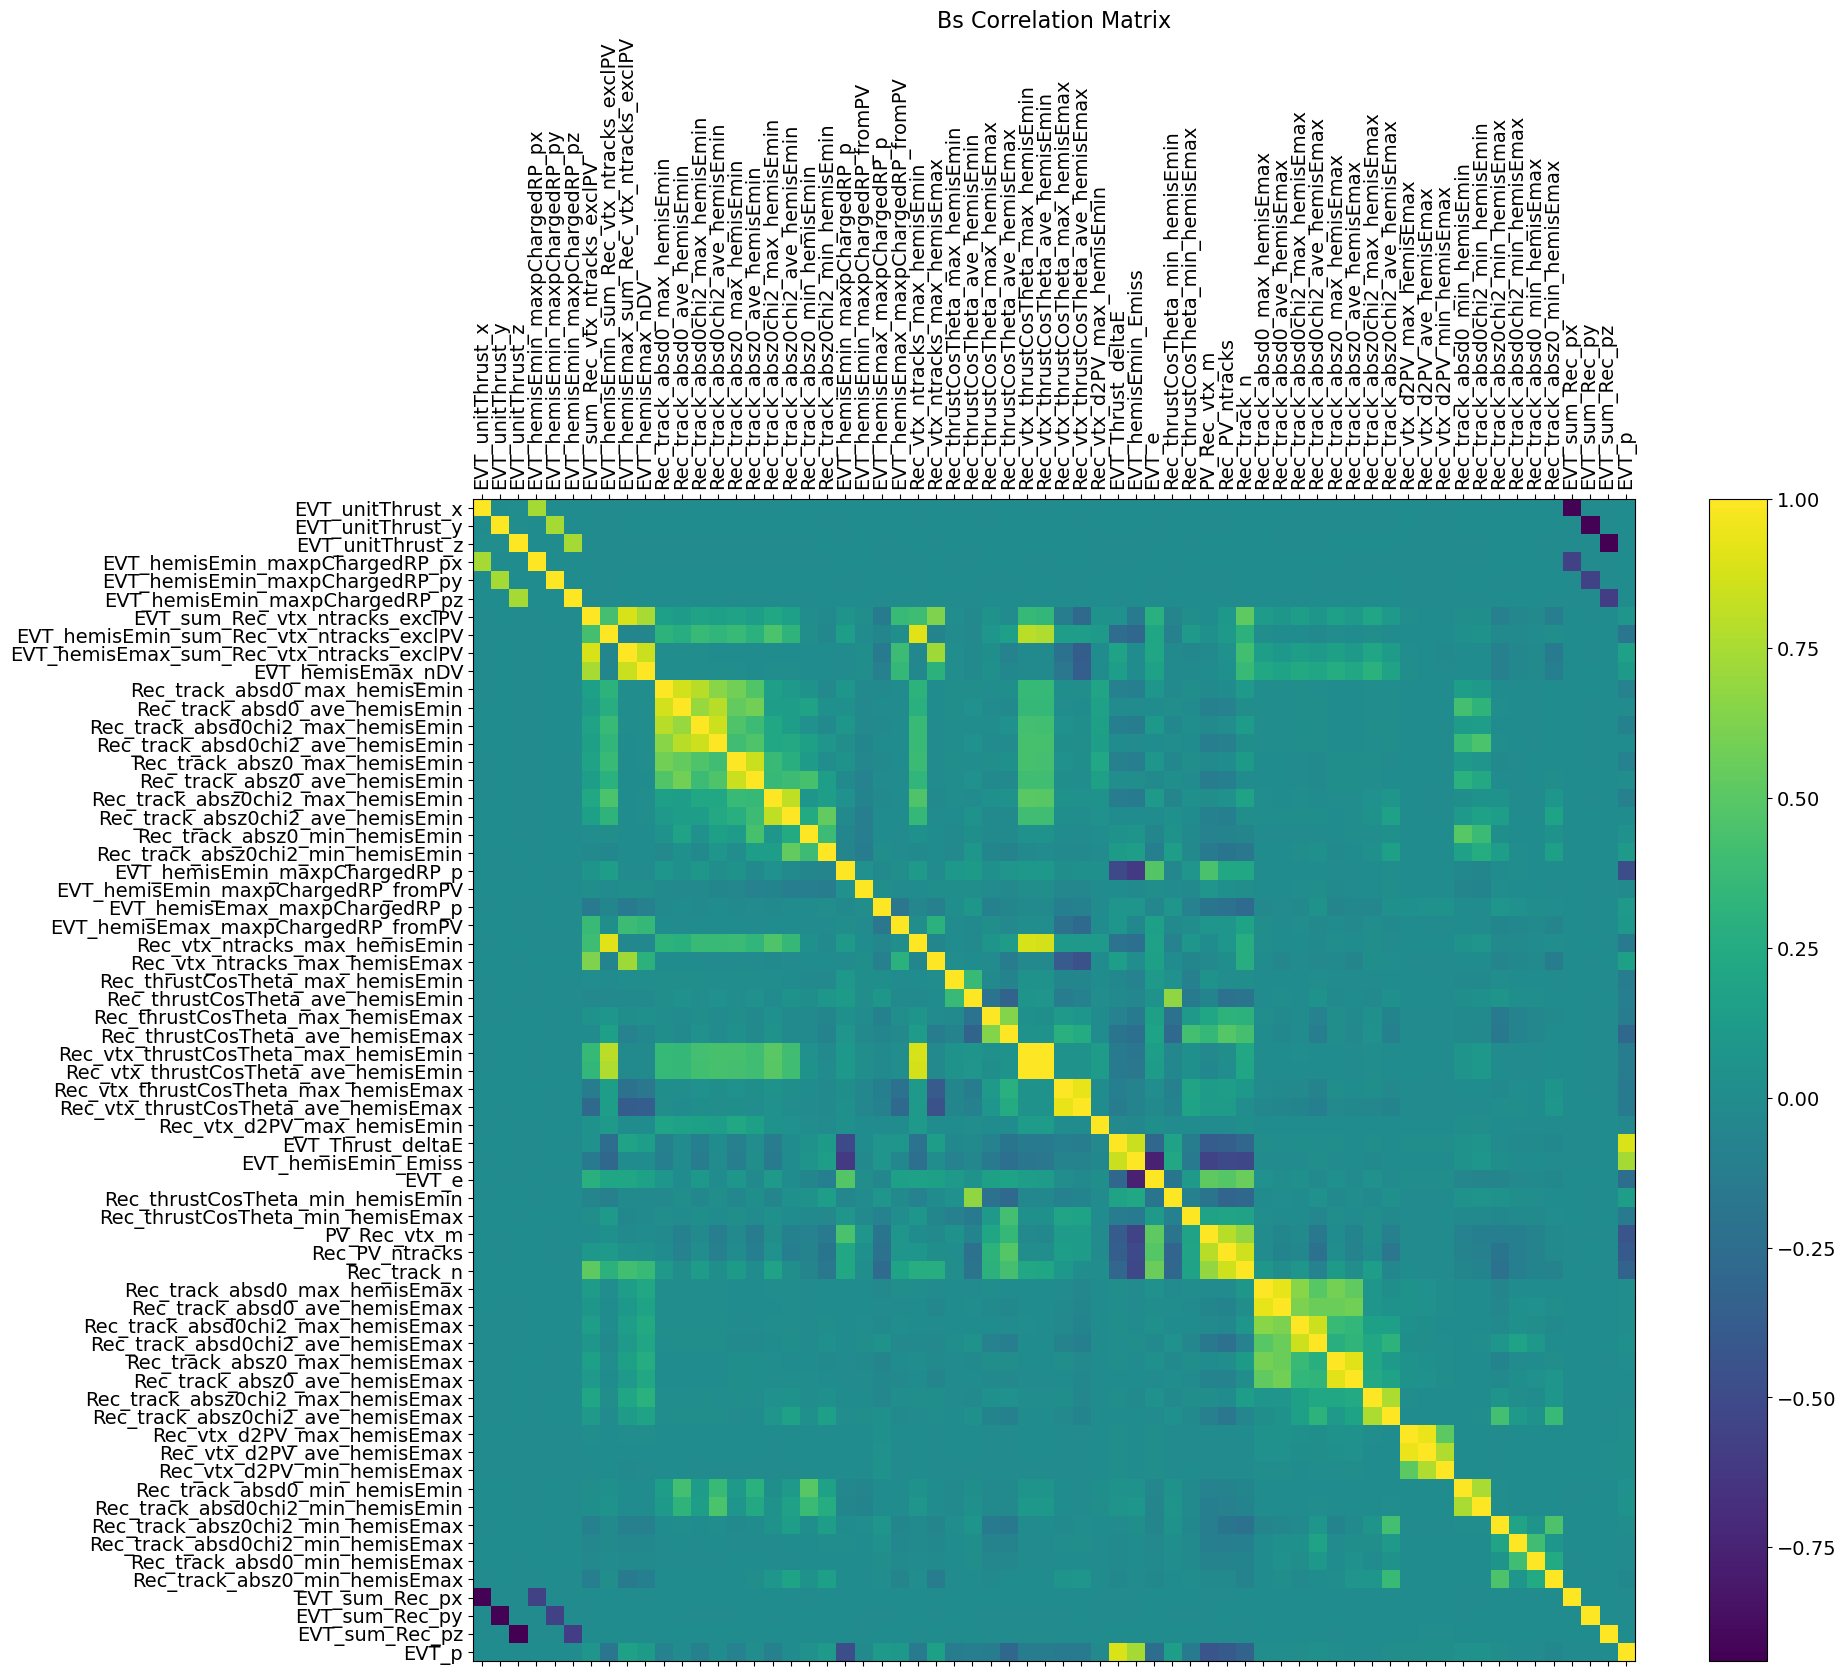

In [17]:
f = plt.figure(figsize=(19, 15))

# Compute correlation matrix 
Bs_correlation_matrix = df_Bs_full.corr()
plt.matshow(Bs_correlation_matrix, fignum=f.number)
# Select numeric columns for ticks and labels 
numeric_columns = df_Bs_full.select_dtypes(['number']).columns
plt.xticks(range(len(numeric_columns)),numeric_columns , fontsize=14, rotation=90)
plt.yticks(range(len(numeric_columns)), numeric_columns, fontsize=14)
cb = plt.colorbar()
cb.ax.tick_params(labelsize=14)
plt.title('Bs Correlation Matrix', fontsize=16)

## Repeat for one hadronic background and taus

### Zud

In [18]:
merged_folder_path = '/r01/lhcb/ejnw2/fcc/FCCAnalyses/examples/FCCee/flavour/B2Inv/outputs/stage2_training_incorrectBSC/full_data_merged/'
#list = ['p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu','p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu','p8_ee_Zbb_ecm91','p8_ee_Zcc_ecm91','p8_ee_Zss_ecm91', 'p8_ee_Zud_ecm91', 'p8_ee_Ztautau_ecm91']
list = cfg.samples

sample = 'p8_ee_Zud_ecm91'
merged_file_path = merged_folder_path + f"{sample}_allchunks.root"

# Create instance of uproot, we have opened the file
uproot_file = uproot.open( merged_file_path )

tree = uproot_file['events']

# define variables we want out
branches = BDT2branchList_subset
#branches = BDT2branchList_corrected 

df_ud_merged = tree.arrays(
    expressions = branches , 
    library = 'pd' ,
)
    

# define variables we want out
branches_pc = problem_children
#branches = BDT2branchList_corrected 

df_ud_problem_children = tree.arrays(
    expressions = branches_pc , 
    library = 'pd' ,
)
    
# close file
uproot_file.close()

# Apply the function to the entire DataFrame using list comprehension
df_ud_cleaned = pd.DataFrame({
    col: [select_first_element(x) for x in df_ud_problem_children[col]]
    for col in df_ud_problem_children.columns
})

df_ud_full = pd.concat([df_ud_merged,df_ud_cleaned],axis=1)

Text(0.5, 1.0, 'Zud Correlation Matrix')

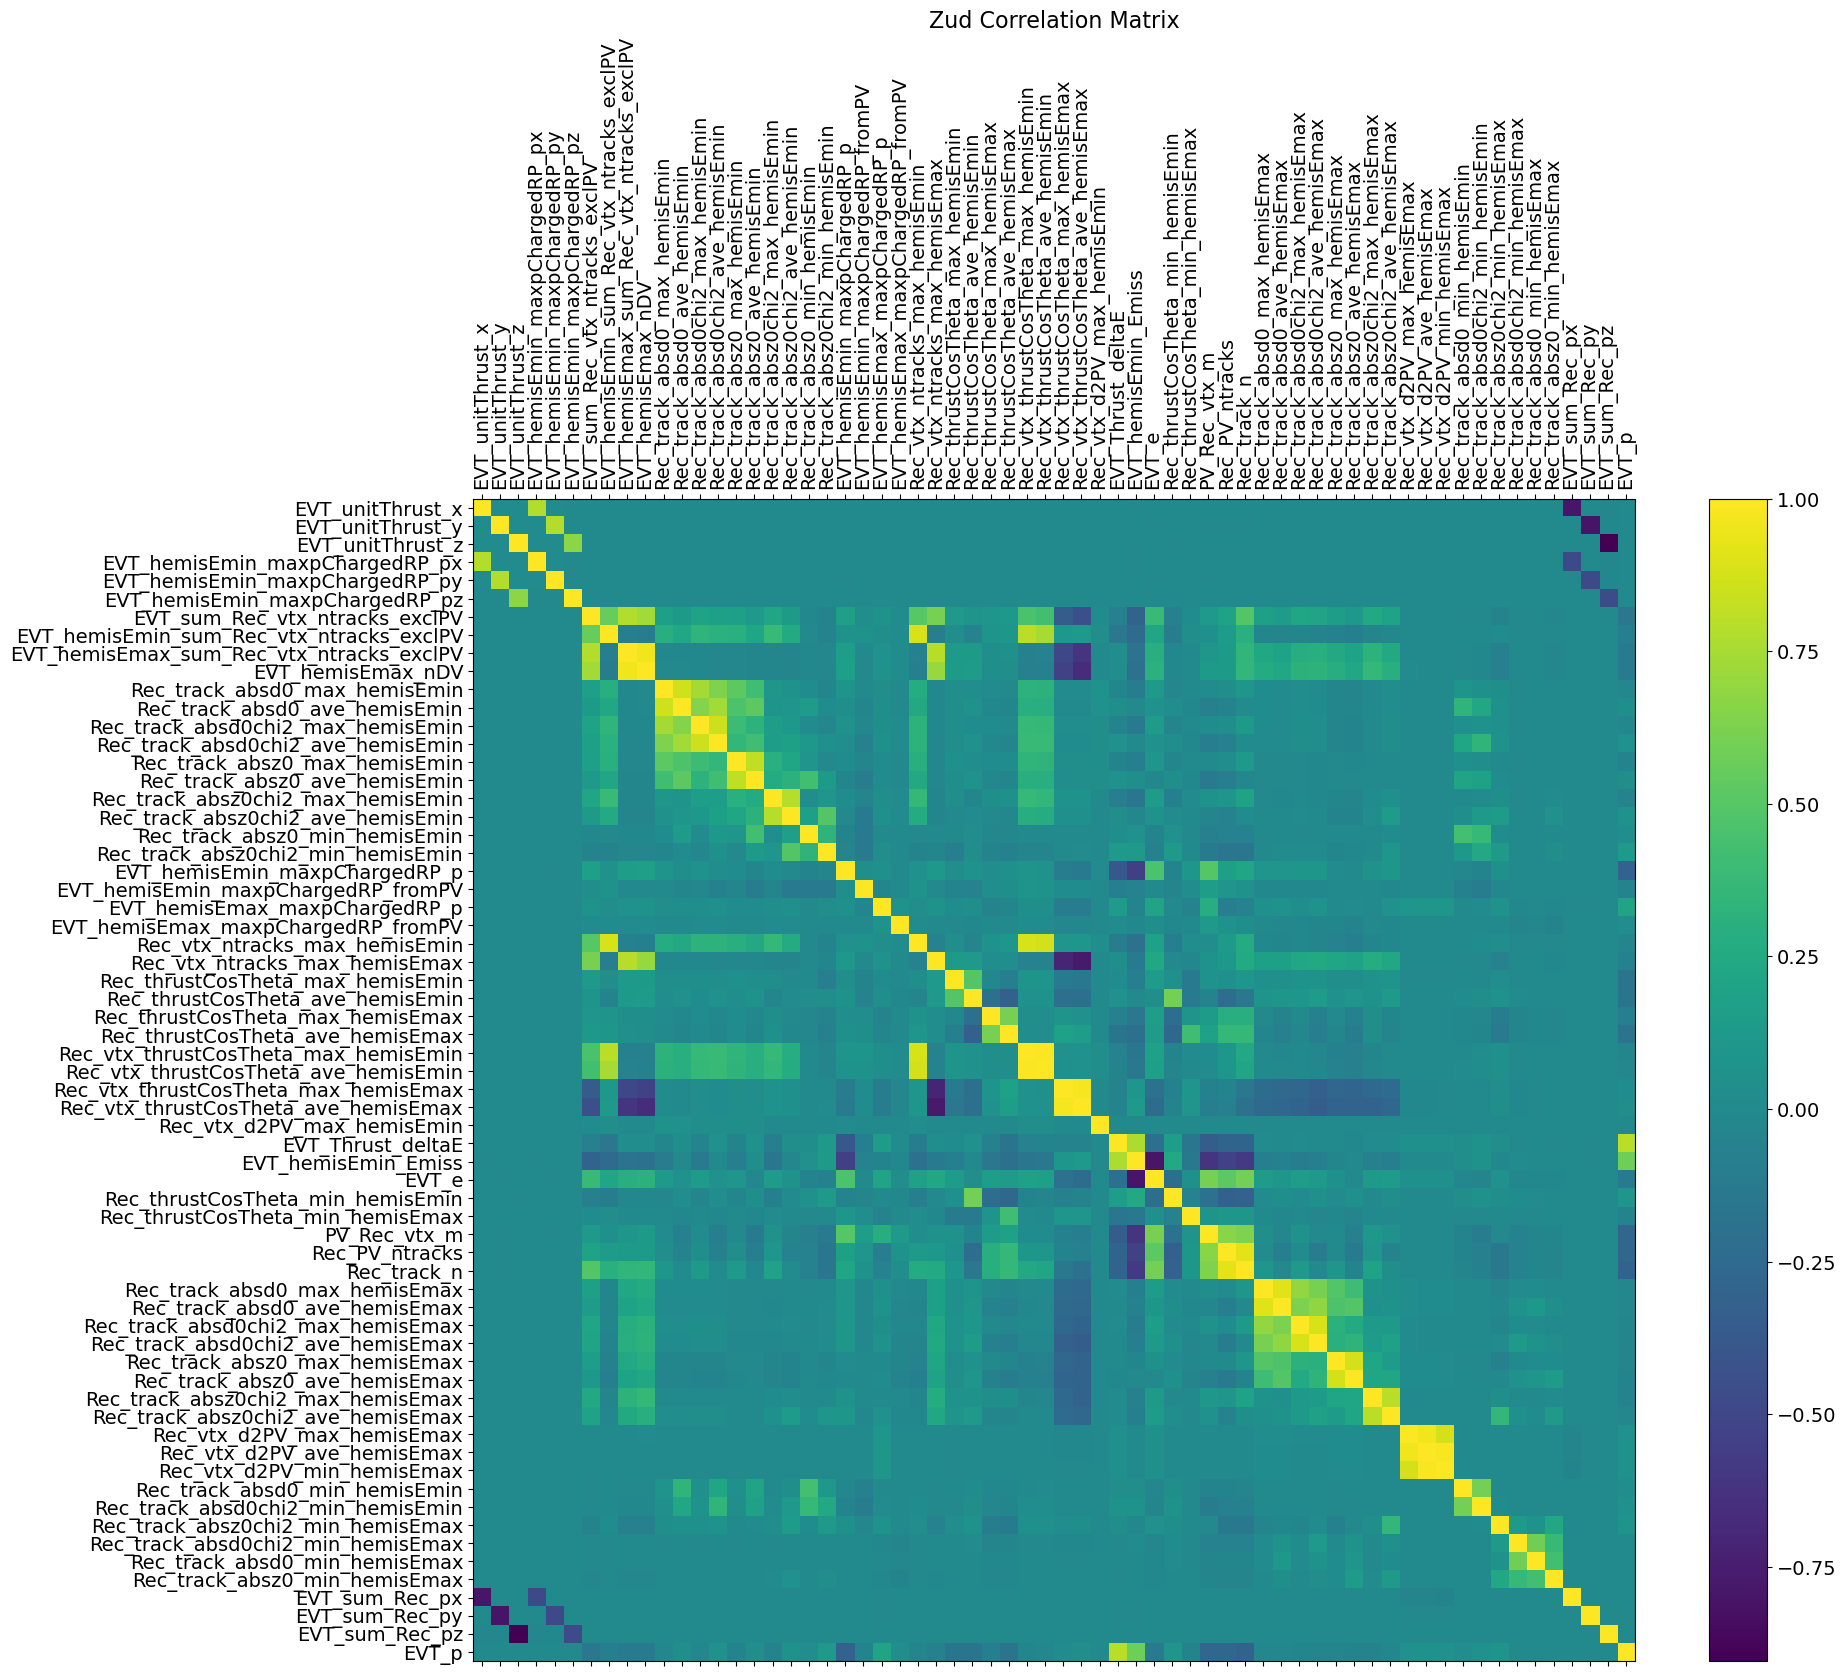

In [19]:
f = plt.figure(figsize=(19, 15))

# Compute correlation matrix 
ud_correlation_matrix = df_ud_full.corr()
plt.matshow(ud_correlation_matrix, fignum=f.number)
# Select numeric columns for ticks and labels 
numeric_columns = df_ud_full.select_dtypes(['number']).columns
plt.xticks(range(len(numeric_columns)),numeric_columns , fontsize=14, rotation=90)
plt.yticks(range(len(numeric_columns)), numeric_columns, fontsize=14)
cb = plt.colorbar()
cb.ax.tick_params(labelsize=14)
plt.title('Zud Correlation Matrix', fontsize=16)

Text(0.5, 1.0, 'Difference in Bs and Zud Correlation Matrix')

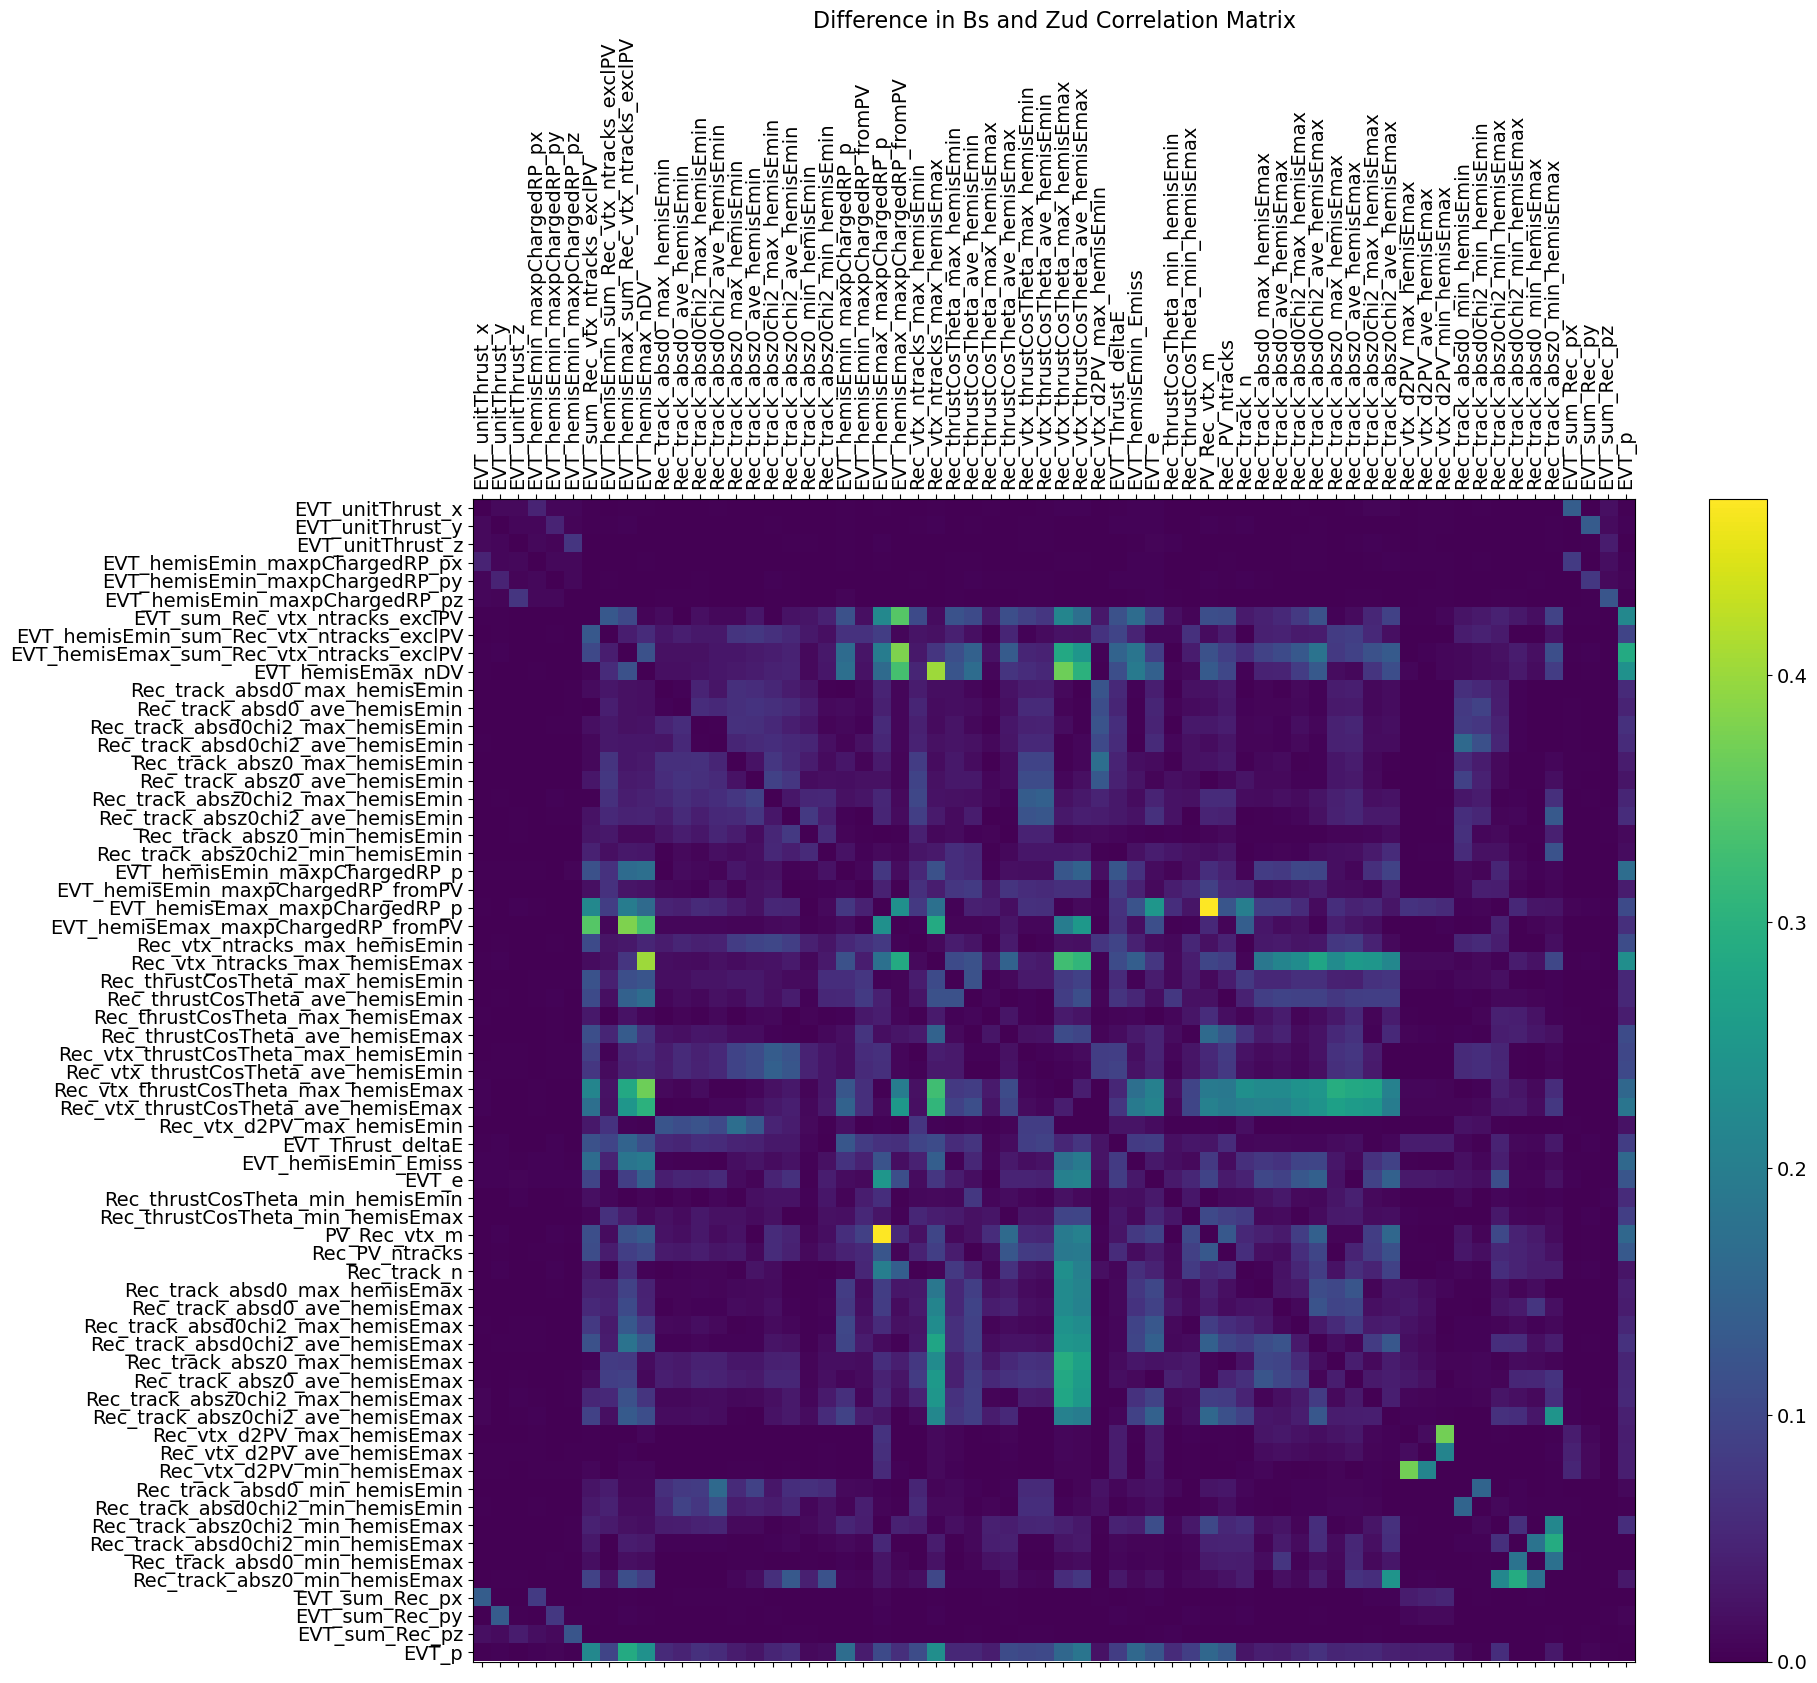

In [24]:
f = plt.figure(figsize=(19, 15))

# Compute correlation matrix 
differenece_corr_matrix_Bsud = abs( Bs_correlation_matrix - ud_correlation_matrix)
plt.matshow(differenece_corr_matrix_Bsud, fignum=f.number)
# Select numeric columns for ticks and labels 
numeric_columns = df_ud_full.select_dtypes(['number']).columns
plt.xticks(range(len(numeric_columns)),numeric_columns , fontsize=14, rotation=90)
plt.yticks(range(len(numeric_columns)), numeric_columns, fontsize=14)
cb = plt.colorbar()
cb.ax.tick_params(labelsize=14)
plt.title('Difference in Bs and Zud Correlation Matrix', fontsize=16)

### Zbb

In [20]:
sample = 'p8_ee_Zbb_ecm91'
merged_file_path = merged_folder_path + f"{sample}_allchunks.root"

# Create instance of uproot, we have opened the file
uproot_file = uproot.open( merged_file_path )

tree = uproot_file['events']

# define variables we want out
branches = BDT2branchList_subset
#branches = BDT2branchList_corrected 

df_bb_merged = tree.arrays(
    expressions = branches , 
    library = 'pd' ,
)
    

# define variables we want out
branches_pc = problem_children
#branches = BDT2branchList_corrected 

df_bb_problem_children = tree.arrays(
    expressions = branches_pc , 
    library = 'pd' ,
)
    
# close file
uproot_file.close()

# Apply the function to the entire DataFrame using list comprehension
df_bb_cleaned = pd.DataFrame({
    col: [select_first_element(x) for x in df_bb_problem_children[col]]
    for col in df_bb_problem_children.columns
})

df_bb_full = pd.concat([df_bb_merged,df_bb_cleaned],axis=1)

Text(0.5, 1.0, 'Zbb Correlation Matrix')

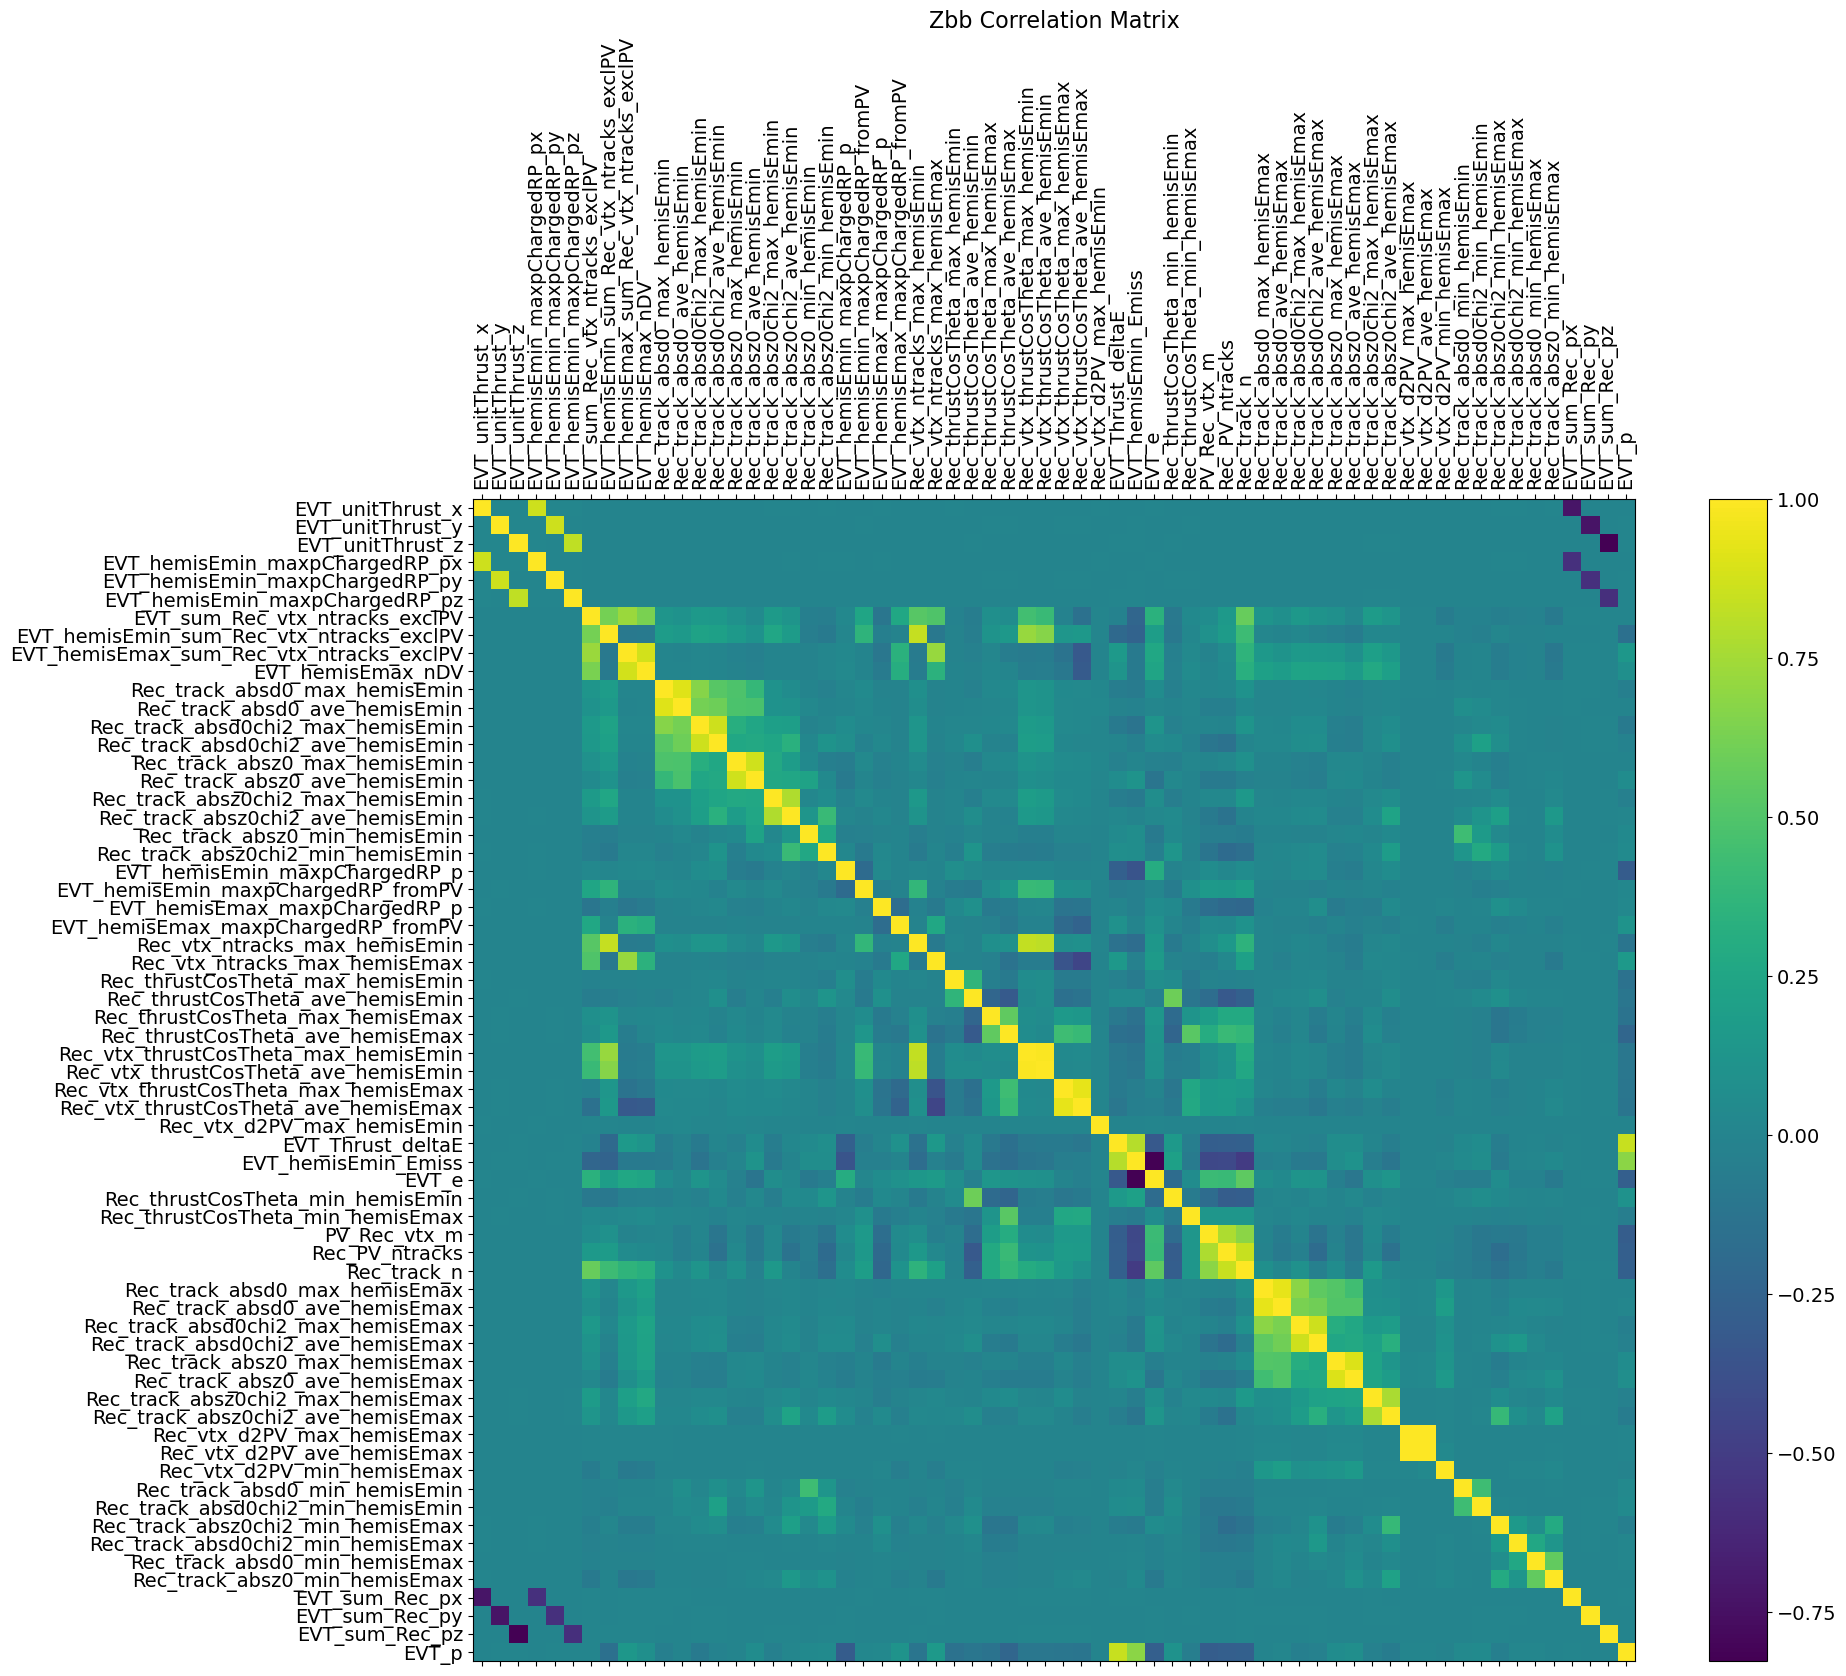

In [21]:
f = plt.figure(figsize=(19, 15))

# Compute correlation matrix 
bb_correlation_matrix = df_bb_full.corr()
plt.matshow(bb_correlation_matrix, fignum=f.number)
# Select numeric columns for ticks and labels 
numeric_columns = df_bb_full.select_dtypes(['number']).columns
plt.xticks(range(len(numeric_columns)),numeric_columns , fontsize=14, rotation=90)
plt.yticks(range(len(numeric_columns)), numeric_columns, fontsize=14)
cb = plt.colorbar()
cb.ax.tick_params(labelsize=14)
plt.title('Zbb Correlation Matrix', fontsize=16)

### Ztautau

In [22]:
merged_folder_path = '/r01/lhcb/ejnw2/fcc/FCCAnalyses/examples/FCCee/flavour/B2Inv/outputs/stage2_training_incorrectBSC/full_data_merged/'

sample = 'p8_ee_Ztautau_ecm91'
merged_file_path = merged_folder_path + f"{sample}_allchunks.root"

# Create instance of uproot, we have opened the file
uproot_file = uproot.open( merged_file_path )

tree = uproot_file['events']

# define variables we want out
branches = BDT2branchList_subset
#branches = BDT2branchList_corrected 

df_tautau_merged = tree.arrays(
    expressions = branches , 
    library = 'pd' ,
)
    

# define variables we want out
branches_pc = problem_children
#branches = BDT2branchList_corrected 

df_tautau_problem_children = tree.arrays(
    expressions = branches_pc , 
    library = 'pd' ,
)
    
# close file
uproot_file.close()

# Apply the function to the entire DataFrame using list comprehension
df_tautau_cleaned = pd.DataFrame({
    col: [select_first_element(x) for x in df_tautau_problem_children[col]]
    for col in df_tautau_problem_children.columns
})

df_tautau_full = pd.concat([df_tautau_merged,df_tautau_cleaned],axis=1)

Text(0.5, 1.0, 'Correlation Matrix')

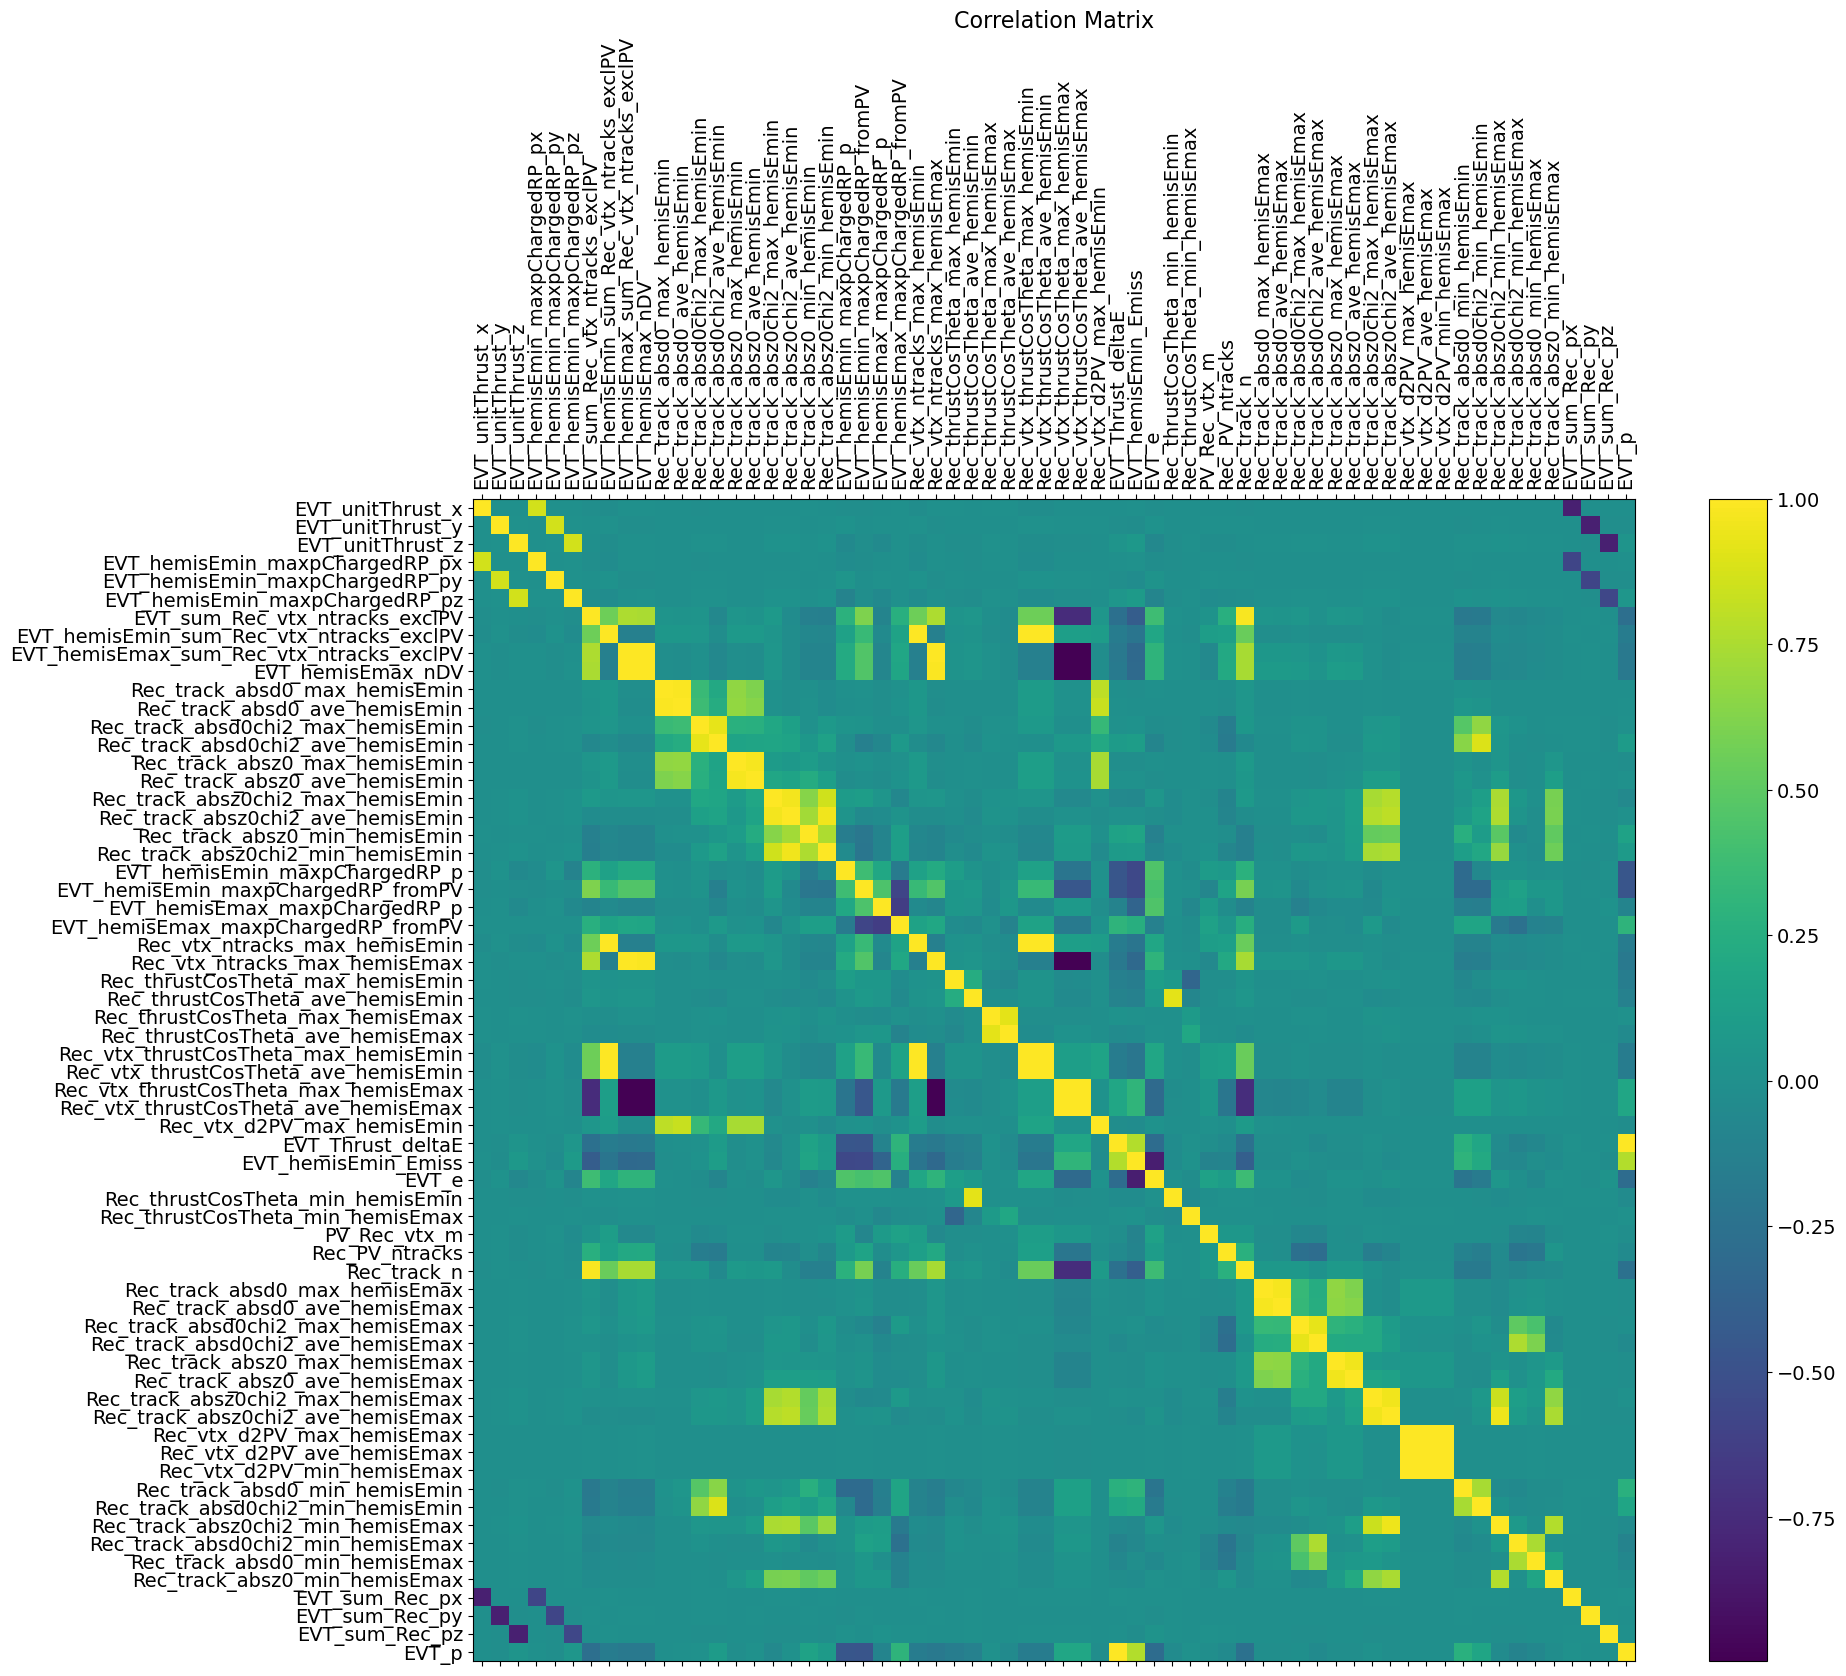

In [23]:
f = plt.figure(figsize=(19, 15))

# Compute correlation matrix 
correlation_matrix = df_tautau_full.corr()
plt.matshow(correlation_matrix, fignum=f.number)
# Select numeric columns for ticks and labels 
numeric_columns = df_tautau_full.select_dtypes(['number']).columns
plt.xticks(range(len(numeric_columns)),numeric_columns , fontsize=14, rotation=90)
plt.yticks(range(len(numeric_columns)), numeric_columns, fontsize=14)
cb = plt.colorbar()
cb.ax.tick_params(labelsize=14)
plt.title('Correlation Matrix', fontsize=16)